# Notebook 1: Exploratory Data Analysis & Data Cleaning
**Project:** Ontario Insurance Claims Intelligence Platform  
**Goal:** Understand the dataset, identify data quality issues, clean and prepare for analysis.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
import os
from pathlib import Path

def find_project_root():
    candidates = []

    # VS Code injects the notebook's absolute path into this variable
    vsc_path = globals().get('__vsc_ipynb_file__')
    if vsc_path:
        candidates.append(Path(vsc_path).parent)

    candidates.append(Path.cwd())

    for start in candidates:
        for folder in [start] + list(start.parents):
            if (folder / 'requirements.txt').exists():
                return folder

    raise FileNotFoundError(
        f"Cannot find project root (requirements.txt not found).\n"
        f"Searched from: {[str(c) for c in candidates]}"
    )

PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)  # Lock the working directory to project root

RAW_DATA       = PROJECT_ROOT / 'data' / 'raw' / 'insurance_claims.csv'
PROCESSED_DATA = PROJECT_ROOT / 'data' / 'processed' / 'insurance_claims_clean.csv'
FIGURES        = PROJECT_ROOT / 'outputs' / 'figures'

print(f"Project root: {PROJECT_ROOT}")
print(f"CSV exists:   {RAW_DATA.exists()}")

df = pd.read_csv(RAW_DATA)
print(f"Shape: {df.shape}")
print(f"Rows:  {df.shape[0]:,}")

Project root: c:\Users\ashmi\Insurance_Claims_Intelligence\Insurance_Claims_Intelligence
CSV exists:   True
Shape: (1000, 40)
Rows:  1,000


## Step 1: Load the Raw Data

## Step 2: First Look — What Does Each Column Contain?

In [3]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation           1000 non-null   object 
 13  insured_hobbies    

In [4]:
# First 5 rows
df.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,capital-gains,capital-loss,incident_date,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_city,incident_location,incident_hour_of_the_day,number_of_vehicles_involved,property_damage,bodily_injuries,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,MALE,MD,craft-repair,sleeping,husband,53300,0,2015-01-25,Single Vehicle Collision,Side Collision,Major Damage,Police,SC,Columbus,9935 4th Drive,5,1,YES,1,2,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,MALE,MD,machine-op-inspct,reading,other-relative,0,0,2015-01-21,Vehicle Theft,?,Minor Damage,Police,VA,Riverwood,6608 MLK Hwy,8,1,?,0,0,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,FEMALE,PhD,sales,board-games,own-child,35100,0,2015-02-22,Multi-vehicle Collision,Rear Collision,Minor Damage,Police,NY,Columbus,7121 Francis Lane,7,3,NO,2,3,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,FEMALE,PhD,armed-forces,board-games,unmarried,48900,-62400,2015-01-10,Single Vehicle Collision,Front Collision,Major Damage,Police,OH,Arlington,6956 Maple Drive,5,1,?,1,2,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,MALE,Associate,sales,board-games,unmarried,66000,-46000,2015-02-17,Vehicle Theft,?,Minor Damage,NaN,NY,Arlington,3041 3rd Ave,20,1,NO,0,1,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


## Step 3: Identify Data Quality Issues

In [5]:
# Issue 1: _c39 is a completely empty trailing column from the CSV export
print("=== Empty / Junk Columns ===")
print(f"_c39 null count: {df['_c39'].isna().sum()} out of {len(df)} rows")
print()

# Issue 2: True missing values
print("=== Missing Values ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_report = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
print(missing_report[missing_report['missing_count'] > 0])
print()

# Issue 3: ? used as placeholder for unknown
print("=== Question Mark Placeholders (treated as missing) ===")
for col in df.select_dtypes(include='object').columns:
    q_count = (df[col] == '?').sum()
    if q_count > 0:
        print(f"  {col}: {q_count} rows contain '?'")

=== Empty / Junk Columns ===
_c39 null count: 1000 out of 1000 rows

=== Missing Values ===
                       missing_count  missing_pct
authorities_contacted             91         9.10
_c39                            1000       100.00

=== Question Mark Placeholders (treated as missing) ===
  collision_type: 178 rows contain '?'
  property_damage: 360 rows contain '?'
  police_report_available: 343 rows contain '?'


## Step 4: Clean the Data

In [6]:
df_clean = df.copy()

# Fix 1: Drop the empty junk column
df_clean = df_clean.drop(columns=['_c39'])
print("Dropped _c39")

# Fix 2: Replace ? with NaN so pandas treats them as missing
cols_with_question = ['collision_type', 'property_damage', 'police_report_available']
for col in cols_with_question:
    before = (df_clean[col] == '?').sum()
    df_clean[col] = df_clean[col].replace('?', np.nan)
    print(f"Replaced {before} '?' values in {col} with NaN")

# Fix 3: Convert date columns to datetime
df_clean['policy_bind_date'] = pd.to_datetime(df_clean['policy_bind_date'])
df_clean['incident_date'] = pd.to_datetime(df_clean['incident_date'])
print("Converted date columns to datetime")

# Fix 4: Standardise fraud_reported to binary integer (1 = fraud, 0 = not fraud)
df_clean['fraud_reported'] = df_clean['fraud_reported'].map({'Y': 1, 'N': 0})
print("Converted fraud_reported to binary (1=fraud, 0=not fraud)")

print(f"\nClean dataset shape: {df_clean.shape}")

Dropped _c39
Replaced 178 '?' values in collision_type with NaN
Replaced 360 '?' values in property_damage with NaN
Replaced 343 '?' values in police_report_available with NaN
Converted date columns to datetime
Converted fraud_reported to binary (1=fraud, 0=not fraud)

Clean dataset shape: (1000, 39)


## Step 5: Engineer Key Features

In [7]:
# Feature 1: Loss ratio — the single most important metric for an insurer
# Loss ratio = claims paid / premiums collected
# > 1.0 means the insurer is paying out more than it collected on that policy
df_clean['loss_ratio'] = df_clean['total_claim_amount'] / df_clean['policy_annual_premium']

# Feature 2: Claim composition — what portion of total claim is each type?
df_clean['injury_pct'] = df_clean['injury_claim'] / df_clean['total_claim_amount']
df_clean['vehicle_pct'] = df_clean['vehicle_claim'] / df_clean['total_claim_amount']
df_clean['property_pct'] = df_clean['property_claim'] / df_clean['total_claim_amount']

# Feature 3: Policy age in days at time of incident
df_clean['policy_age_days'] = (df_clean['incident_date'] - df_clean['policy_bind_date']).dt.days

# Feature 4: Vehicle age at time of incident
df_clean['vehicle_age'] = 2015 - df_clean['auto_year']

print("Engineered features:")
print(df_clean[['loss_ratio', 'injury_pct', 'vehicle_pct', 'property_pct', 'policy_age_days', 'vehicle_age']].describe())

Engineered features:
       loss_ratio  injury_pct  vehicle_pct  property_pct  policy_age_days  \
count     1000.00     1000.00      1000.00       1000.00          1000.00   
mean        43.77        0.14         0.72          0.14          4739.14   
std         24.64        0.05         0.06          0.05          2686.43   
min          0.07        0.00         0.56          0.00           -20.00   
25%         32.35        0.10         0.69          0.10          2484.00   
50%         44.98        0.12         0.73          0.12          4682.00   
75%         58.69        0.18         0.78          0.18          7068.00   
max        157.99        0.30         1.00          0.33          9172.00   

       vehicle_age  
count      1000.00  
mean          9.90  
std           6.02  
min           0.00  
25%           5.00  
50%          10.00  
75%          15.00  
max          20.00  


## Step 6: Key Business Statistics

In [8]:
print("=" * 50)
print("KEY BUSINESS STATISTICS")
print("=" * 50)

total_premiums = df_clean['policy_annual_premium'].sum()
total_claims = df_clean['total_claim_amount'].sum()
overall_loss_ratio = total_claims / total_premiums

print(f"\nTotal Premiums Collected:  ${total_premiums:>12,.0f}")
print(f"Total Claims Paid:         ${total_claims:>12,.0f}")
print(f"Overall Loss Ratio:        {overall_loss_ratio:>12.2f}x")
print(f"\nFraud Rate:                {df_clean['fraud_reported'].mean()*100:.1f}%")
print(f"Fraudulent Claims:         {df_clean['fraud_reported'].sum()} of {len(df_clean)}")
print(f"\nAvg Claim Amount:          ${df_clean['total_claim_amount'].mean():>12,.0f}")
print(f"Avg Fraudulent Claim:      ${df_clean[df_clean['fraud_reported']==1]['total_claim_amount'].mean():>12,.0f}")
print(f"Avg Legitimate Claim:      ${df_clean[df_clean['fraud_reported']==0]['total_claim_amount'].mean():>12,.0f}")

KEY BUSINESS STATISTICS

Total Premiums Collected:  $   1,256,406
Total Claims Paid:         $  52,761,940
Overall Loss Ratio:               41.99x

Fraud Rate:                24.7%
Fraudulent Claims:         247 of 1000

Avg Claim Amount:          $      52,762
Avg Fraudulent Claim:      $      60,302
Avg Legitimate Claim:      $      50,289


## Step 7: Visualisations

Chart saved to outputs/figures/


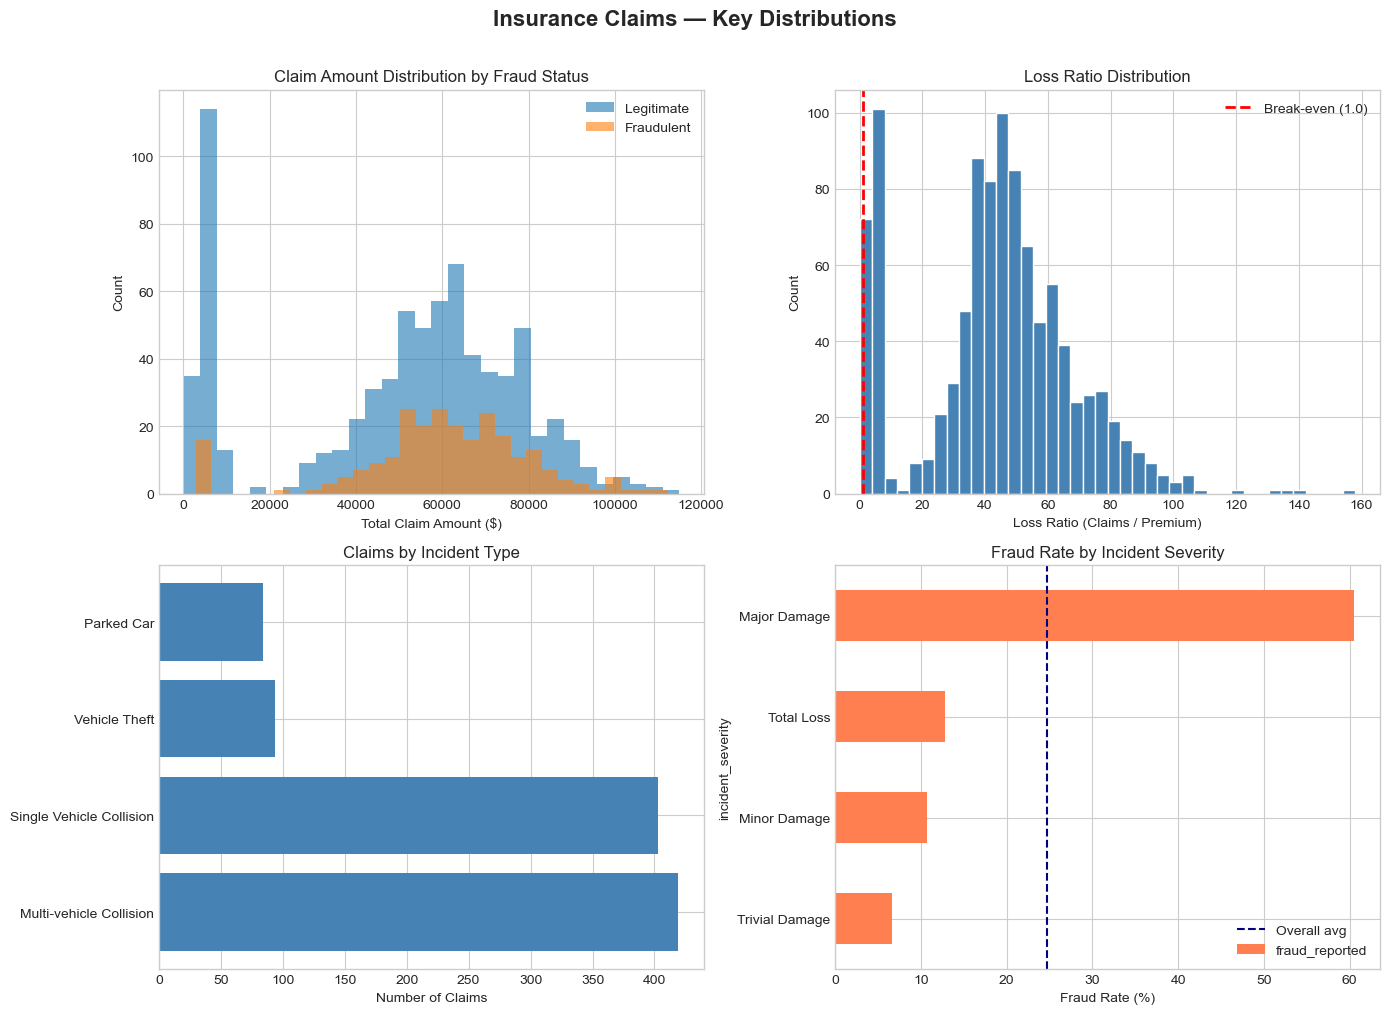

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Insurance Claims — Key Distributions', fontsize=16, fontweight='bold', y=1.01)

# Chart 1: Claim amount distribution by fraud status
fraud_labels = {0: 'Legitimate', 1: 'Fraudulent'}
for fraud_val, label in fraud_labels.items():
    subset = df_clean[df_clean['fraud_reported'] == fraud_val]['total_claim_amount']
    axes[0,0].hist(subset, bins=30, alpha=0.6, label=label)
axes[0,0].set_title('Claim Amount Distribution by Fraud Status')
axes[0,0].set_xlabel('Total Claim Amount ($)')
axes[0,0].set_ylabel('Count')
axes[0,0].legend()

# Chart 2: Loss ratio distribution
axes[0,1].hist(df_clean['loss_ratio'], bins=40, color='steelblue', edgecolor='white')
axes[0,1].axvline(1.0, color='red', linestyle='--', linewidth=2, label='Break-even (1.0)')
axes[0,1].set_title('Loss Ratio Distribution')
axes[0,1].set_xlabel('Loss Ratio (Claims / Premium)')
axes[0,1].set_ylabel('Count')
axes[0,1].legend()

# Chart 3: Incident type breakdown
incident_counts = df_clean['incident_type'].value_counts()
axes[1,0].barh(incident_counts.index, incident_counts.values, color='steelblue')
axes[1,0].set_title('Claims by Incident Type')
axes[1,0].set_xlabel('Number of Claims')

# Chart 4: Fraud rate by incident severity
fraud_by_severity = df_clean.groupby('incident_severity')['fraud_reported'].mean() * 100
fraud_by_severity.sort_values().plot(kind='barh', ax=axes[1,1], color='coral')
axes[1,1].set_title('Fraud Rate by Incident Severity')
axes[1,1].set_xlabel('Fraud Rate (%)')
axes[1,1].axvline(df_clean['fraud_reported'].mean()*100, color='navy', linestyle='--', label='Overall avg')
axes[1,1].legend()

plt.tight_layout()
FIGURES.mkdir(parents=True, exist_ok=True)
plt.savefig(FIGURES / '01_key_distributions.png', dpi=150, bbox_inches='tight')
print("Chart saved to outputs/figures/")

## Step 8: Save Clean Dataset

In [10]:
PROCESSED_DATA.parent.mkdir(parents=True, exist_ok=True)
df_clean.to_csv(PROCESSED_DATA, index=False)
print(f"Clean dataset saved: data/processed/insurance_claims_clean.csv")
print(f"Shape: {df_clean.shape}")
print(f"Columns added: loss_ratio, injury_pct, vehicle_pct, property_pct, policy_age_days, vehicle_age")

Clean dataset saved: data/processed/insurance_claims_clean.csv
Shape: (1000, 45)
Columns added: loss_ratio, injury_pct, vehicle_pct, property_pct, policy_age_days, vehicle_age


## Summary of Findings

| Issue Found | How We Fixed It |
|-------------|----------------|
| `_c39` empty junk column | Dropped entirely |
| `?` in 3 columns | Replaced with NaN |
| Date columns stored as strings | Converted to datetime |
| `fraud_reported` as Y/N string | Converted to 1/0 integer |
